In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import joblib

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

ЭТАП 1: Анализ данных (EDA)

In [3]:
# 1.	Загрузить датасет (из Kaggle или другого источника) и вывести первые 10 строк.
df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
#2.	Посмотреть .info(), .shape, .describe().
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.shape

(1000, 8)

In [6]:
df.describe

<bound method NDFrame.describe of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72             74  
1                 completed          69             90             88  
2                      none          90             95             93  
3                      none          47             57             44  
4                      none          76             78             75  
..                      ...         ...            ...            ...  
995               completed          88             99             95  
996                    none          62             55             55  
997               completed          59             71             65  
998               completed          68             78             77  
999                    none          77             86             86  

[1000 rows x 8 columns]>

In [7]:
# 3.	Вывести список колонок и их типы.
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [8]:
#4.	Проверить на пропущенные значения.
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [9]:
#5.	Сохранить очищенный датафрейм в students_clean.csv.
df.to_csv('students_clean.csv', index=False)

In [10]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [11]:
#6.	Сколько уникальных значений у race/ethnicity?
df['race/ethnicity'].nunique()

5

In [12]:
#7.	Топ-3 самых высоких средних оценок по математике среди этнических групп.

df.groupby('race/ethnicity')['math score'].mean().sort_values(ascending=False).head(3).round(2)

,math score
race/ethnicity,
group E,73.82
group D,67.36
group C,64.46


In [13]:
#8.	Сколько учеников прошли курс подготовки (test preparation course)?
(df['test preparation course'] == 'completed').sum()

np.int64(358)

In [14]:
#9.	Средняя оценка по математике среди тех, кто прошел курс.
df.groupby('test preparation course')['math score'].mean().round(2)

,math score
test preparation course,
completed,69.70
none,64.08


In [15]:
#10.	Средняя оценка по чтению среди учеников с бесплатным питанием (lunch == free/reduced).
lunch_free = df[df['lunch'] == 'free/reduced']
lunch_free.groupby('lunch')['reading score'].mean().round()

,reading score
lunch,
free/reduced,65.0


In [16]:
#11.	Сколько учеников с уровнем образования родителей bachelor's degree?

(df['parental level of education'] == "bachelor's degree").sum()

np.int64(118)

In [17]:
#14.	Средний балл по математике по уровню образования родителей.

df.groupby('parental level of education')['math score'].mean().round().sort_values(ascending=False)

,math score
parental level of education,
master's degree,70.0
bachelor's degree,69.0
associate's degree,68.0
some college,67.0
some high school,63.0
high school,62.0


In [18]:
#17.    У скольких учеников math score >= 90?

(df['math score'] >= 90).sum()

np.int64(58)

In [19]:
#20.	Создать новый столбец average_score = среднее из трех оценок.

df['avarage_score'] = ((df['math score'] + df['reading score'] + df['writing score'])/3).round(2)

In [20]:
# 12.	Средние баллы по всем предметам по полу (gender).
df.groupby('gender')[['math score','reading score','writing score']].mean().round(2)

,math score,reading score,writing score
gender,,,
female,63.63,72.61,72.47
male,68.73,65.47,63.31


In [21]:
# 13.	У кого медианная оценка по письму выше — мужчины или женщины?
df.groupby('gender')['writing score'].median().round(2)

,writing score
gender,
female,74.0
male,64.0


In [22]:
# 15.	Группировка по test preparation course и lunch + средние оценки.
df.groupby(['test preparation course','lunch'])[['math score','reading score','writing score']].mean().round(2)

math score  reading score  writing score
test preparation course lunch                                                 
completed               free/reduced       63.05          69.87          70.35
                        standard           73.53          76.22          76.77
none                    free/reduced       56.51          61.60          58.74
                        standard           68.13          69.18          67.60

In [23]:
# 16.	Найти самого успешного ученика (максимум по сумме 3 оценок).
df['3 subjects'] = df['math score'] + df['reading score'] + df['writing score']

In [24]:
df[df['3 subjects'] == 300]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,avarage_score,3 subjects
458,female,group E,bachelor's degree,standard,none,100,100,100,100.0,300
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.0,300
962,female,group E,associate's degree,standard,none,100,100,100,100.0,300


In [25]:
# 18.	У скольких учеников все три оценки больше 80?

(df['3 subjects'] >= 80).sum()

np.int64(994)

In [26]:
# 19.	Группировка по gender, race/ethnicity, mean().
df.groupby(['gender','race/ethnicity'])[['math score','reading score','writing score']].mean().round(2)

math score  reading score  writing score
gender race/ethnicity                                          
female group A              58.53          69.00          67.86
       group B              61.40          71.08          70.05
       group C              62.03          71.94          71.78
       group D              65.25          74.05          75.02
       group E              70.81          75.84          75.54
male   group A              63.74          61.74          59.15
       group B              65.93          62.85          60.22
       group C              67.61          65.42          62.71
       group D              69.41          66.14          65.41
       group E              76.75          70.30          67.39

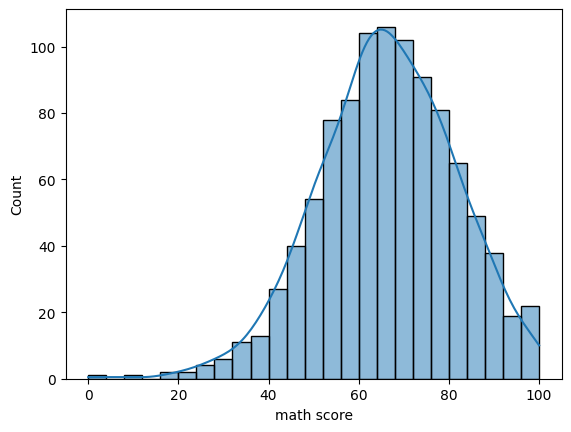

In [27]:
# 41.	Построить histplot для math score.
sns.histplot(data=df, x ='math score', kde=True)
plt.show()

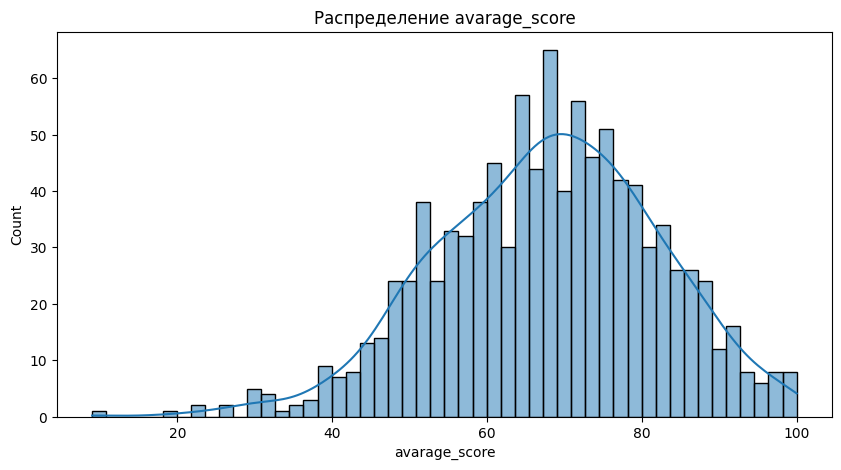

In [28]:
# 42.	Распределение average_score.
plt.figure(figsize=(10,5))
sns.histplot(data=df, x ='avarage_score', kde=True, bins=50)
plt.title('Распределение avarage_score')
plt.savefig('avarage_score.png')
plt.show()

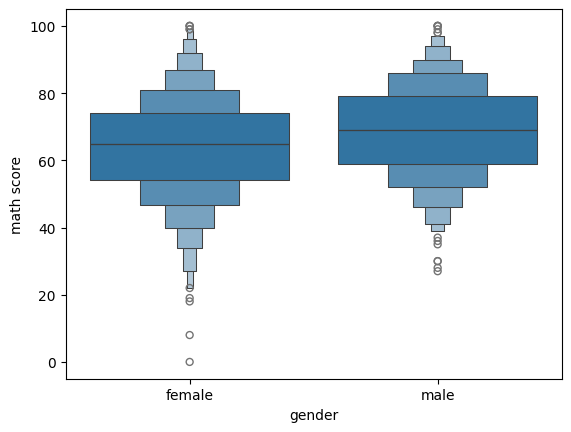

In [29]:
# 43.	boxplot: gender vs math score.
sns.boxenplot(data=df, x='gender', y='math score')
plt.show()

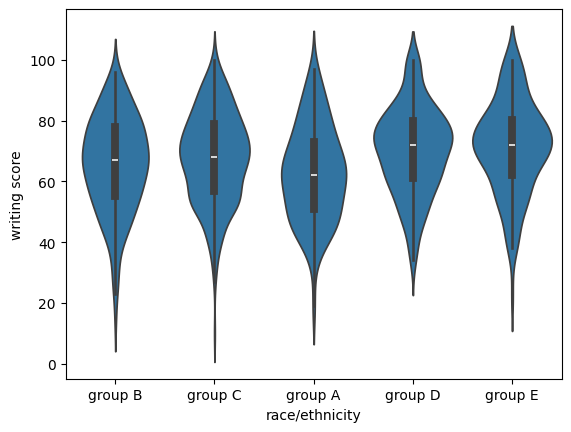

In [30]:
# 44.	violinplot: race/ethnicity vs writing score.
sns.violinplot(data=df, x='race/ethnicity' , y='writing score')
plt.show()

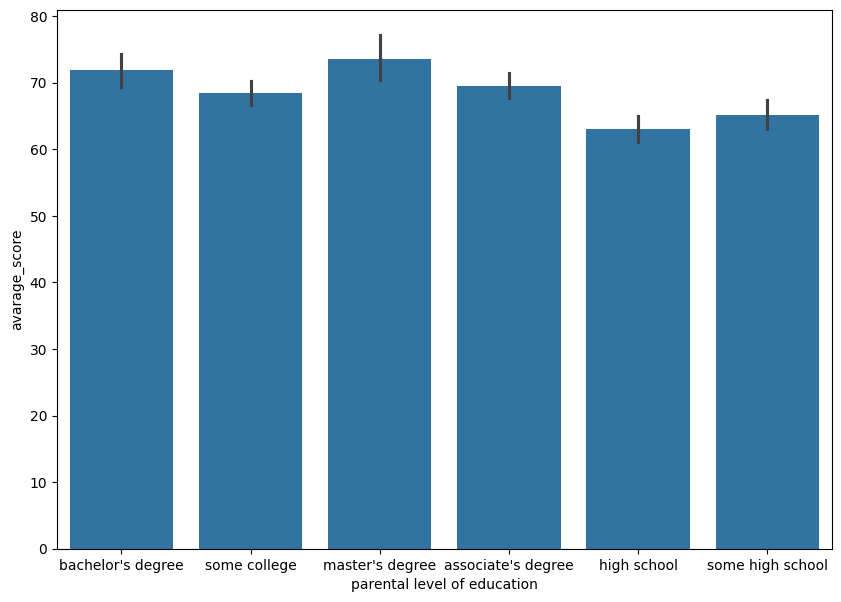

In [31]:
# 45.	barplot: средние оценки по parental level of education.
plt.figure(figsize=(10,7))
sns.barplot(data=df, x='parental level of education', y='avarage_score')
plt.show()

In [32]:
df.head(1)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,avarage_score,3 subjects
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67,218


In [33]:
# 51.	Закодировать категориальные переменные (LabelEncoder или OneHot).
df = pd.get_dummies(df, columns=['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course'], drop_first=True).astype(int)

In [34]:
df.columns

Index(['math score', 'reading score', 'writing score', 'avarage_score',
       '3 subjects', 'gender_male', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')

In [35]:
#52.	Нормализовать числовые признаки (StandardScaler).
scaler = StandardScaler()
features = df.drop(columns=['writing score'])
scaled_data = scaler.fit_transform(features)

In [36]:
# 54.	Разделить X и y (y = math score).
x = scaled_data
y = df['writing score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
# 56.	Построить LinearRegression() модель.
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [38]:
y_predict = model.predict(x_test)
r2_score(y_predict, y_test)

1.0

In [39]:
joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [40]:
df.columns

Index(['math score', 'reading score', 'writing score', 'avarage_score',
       '3 subjects', 'gender_male', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')